# **1. Import Library & dataset**

In [75]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [76]:
from google.colab import drive
drive.mount('/content/drive')
train_path = '/content/drive/MyDrive/Colab Notebooks/car/train'
valid_path   = '/content/drive/MyDrive/Colab Notebooks/car/valid'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Feature Extraction**

In [77]:
def extract_features(img):
    img = cv2.resize(img, (64, 64))

    hist = cv2.calcHist([img], [0,1,2], None,
                        [8,8,8],
                        [0,256,0,256,0,256])

    hist = cv2.normalize(hist, hist).flatten()
    return hist

# **3. Load Dataset**

In [78]:
def load_dataset(path):
    data = []
    labels = []

    images_path = os.path.join(path, 'images')
    labels_path = os.path.join(path, 'labels')

    for file in os.listdir(images_path):
        if file.lower().endswith(('.jpg','.png','.jpeg')):

            img_path = os.path.join(images_path, file)
            label_path = os.path.join(labels_path, file.replace('.jpg', '.txt'))

            img = cv2.imread(img_path)
            if img is None:
                continue

            features = extract_features(img)

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    line = f.readline()
                    if line.strip(): # Check if the line is not empty or just whitespace
                        label = line.split()[0]
                    else:
                        continue # Skip if label line is empty
            else:
                continue

            data.append(features)
            labels.append(label)

    return np.array(data), np.array(labels)

In [79]:
X_train, y_train = load_dataset(train_path)
X_test, y_test   = load_dataset(valid_path)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3527, 512)
Test: (801, 512)


# **4. Hapus data duplikat**

In [80]:
X_train_bytes = [x.tobytes() for x in X_train]

X_test_clean = []
y_test_clean = []

for i in range(len(X_test)):
    if X_test[i].tobytes() not in X_train_bytes:
        X_test_clean.append(X_test[i])
        y_test_clean.append(y_test[i])

X_test = np.array(X_test_clean)
y_test = np.array(y_test_clean)

print("Test setelah dibersihkan:", X_test.shape)

Test setelah dibersihkan: (747, 512)


# **5. Training KNN**

In [81]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# **6. Evaluasi**

In [82]:
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("\nAkurasi:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Akurasi: 0.5274431057563588

Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.51      0.46        68
           1       0.38      0.60      0.46        50
          10       0.52      0.69      0.59        68
          11       0.48      0.57      0.52        74
          12       0.42      0.58      0.48        52
          13       0.56      0.45      0.50        33
          14       0.88      0.78      0.83        76
           3       0.52      0.46      0.49        48
           4       0.14      0.13      0.14        15
           5       0.60      0.47      0.53        53
           6       0.62      0.91      0.74        23
           7       0.44      0.23      0.30        69
           8       0.69      0.39      0.50        51
           9       0.73      0.45      0.56        67

    accuracy                           0.53       747
   macro avg       0.53      0.52      0.51       747
weighted avg       0.55   

# **7. Grafik Akurasi**

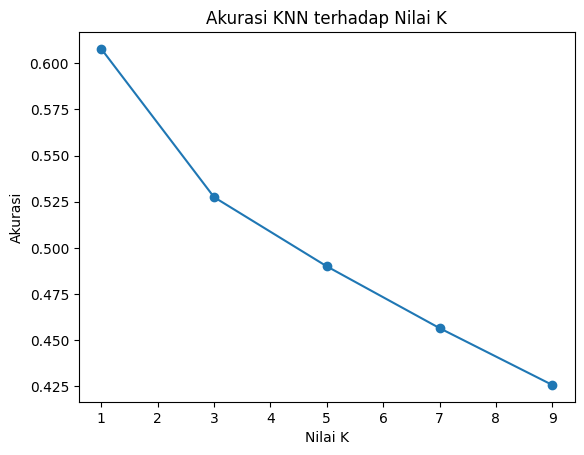

In [92]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title('Akurasi KNN terhadap Nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.show()

# **8. Heatmap**

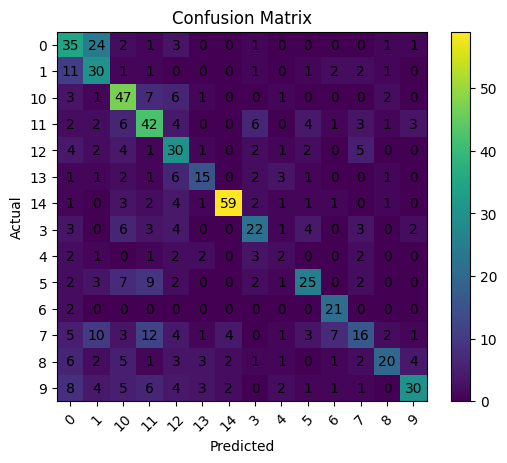

In [84]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()

classes = sorted(list(set(y_test)))

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# **9. memastikan apakah masih ada data duplicate**

In [85]:
import hashlib

def hash_array(arr):
    return hashlib.md5(arr.tobytes()).hexdigest()

train_hash = set([hash_array(x) for x in X_train])
test_hash  = set([hash_array(x) for x in X_test])

same = train_hash.intersection(test_hash)

print("Data sama di train & test:", len(same))

Data sama di train & test: 0
